# Step 19 — Decision layer and reorder recommendations

## Step 19.0 — creation of a new notebook

In [1]:
import pandas as pd
import numpy as np

In [2]:
model_df = pd.read_csv("data/processed/modeling_data_features.csv")
model_df["date"] = pd.to_datetime(model_df["date"])

## Step 19.1 — rebuild a clean decision dataset

In [3]:
decision_df = model_df.dropna(subset=[
    "avg_daily_sales_7",
    "avg_daily_sales_14",
    "days_until_stockout"
]).copy()

In [4]:
decision_df.shape

(2232600, 37)

## Step 19.2 — creation of  forecasted next-day demand proxy

In [5]:
decision_df["forecast_next_day_sales"] = decision_df["rolling_mean_7"]
decision_df["forecast_next_7_days"] = decision_df["rolling_mean_7"] * 7

## Step 19.3 — create recommendation rules

In [6]:
conditions = [
    decision_df["days_until_stockout"] < decision_df["supplier_lead_time"],
    (decision_df["days_until_stockout"] >= decision_df["supplier_lead_time"]) &
    (decision_df["days_until_stockout"] < decision_df["supplier_lead_time"] + 3),
    (decision_df["simulated_stock_on_hand"] > decision_df["forecast_next_7_days"] * 2),
]

choices = [
    "Reorder now",
    "Reorder soon",
    "Overstock risk"
]

decision_df["recommended_action"] = np.select(
    conditions,
    choices,
    default="Safe"
)

In [7]:
decision_df[[
    "date", "store_nbr", "family",
    "simulated_stock_on_hand",
    "forecast_next_7_days",
    "days_until_stockout",
    "supplier_lead_time",
    "recommended_action"
]].head(20)

,date,store_nbr,family,simulated_stock_on_hand,forecast_next_7_days,days_until_stockout,supplier_lead_time,recommended_action
14,2013-01-15,1,AUTOMOTIVE,21.0,15.0,9.800000,4.0,Safe
15,2013-01-16,1,AUTOMOTIVE,22.0,14.0,11.000000,4.0,Safe
16,2013-01-17,1,AUTOMOTIVE,21.0,13.0,11.307692,4.0,Safe
17,2013-01-18,1,AUTOMOTIVE,20.0,12.0,11.666667,4.0,Safe
18,2013-01-19,1,AUTOMOTIVE,18.0,9.0,14.000000,4.0,Safe
19,2013-01-20,1,AUTOMOTIVE,18.0,12.0,10.500000,4.0,Safe
20,2013-01-21,1,AUTOMOTIVE,19.0,13.0,10.230769,4.0,Safe
21,2013-01-22,1,AUTOMOTIVE,19.0,12.0,11.083333,4.0,Safe
22,2013-01-23,1,AUTOMOTIVE,19.0,12.0,11.083333,4.0,Safe
23,2013-01-24,1,AUTOMOTIVE,19.0,14.0,9.500000,4.0,Safe


## Step 19.4 — create priority rank score

In [8]:
decision_df["priority_score"] = (
    decision_df["predicted_stockout_score"]
    if "predicted_stockout_score" in decision_df.columns
    else 0
)

In [9]:
# Since that column probably does not exist in this file, we use a rule-based score instead:
decision_df["priority_score"] = (
    (decision_df["reorder_point"] - decision_df["simulated_stock_on_hand"]).clip(lower=0)
    + (7 - decision_df["days_until_stockout"]).clip(lower=0)
)

## Step 19.5 — rank items by urgency

In [10]:
decision_df["priority_rank"] = decision_df["priority_score"].rank(
    method="dense",
    ascending=False
)

In [11]:
decision_df.sort_values("priority_score", ascending=False)[[
    "date", "store_nbr", "family",
    "simulated_stock_on_hand",
    "reorder_point",
    "days_until_stockout",
    "recommended_action",
    "priority_score",
    "priority_rank"
]].head(20)

,date,store_nbr,family,simulated_stock_on_hand,reorder_point,days_until_stockout,recommended_action,priority_score,priority_rank
1727607,2017-02-20,32,BEAUTY,1.0,1.0,3.5,Reorder now,3.5,1.0
225584,2017-06-05,5,BABY CARE,1.0,1.0,3.5,Reorder now,3.5,1.0
2336433,2014-12-29,43,BABY CARE,1.0,1.0,3.5,Reorder now,3.5,1.0
872868,2014-07-12,16,MAGAZINES,1.0,1.0,3.5,Reorder now,3.5,1.0
872765,2014-03-31,16,MAGAZINES,1.0,1.0,3.5,Reorder now,3.5,1.0
872741,2014-03-07,16,MAGAZINES,1.0,1.0,3.5,Reorder now,3.5,1.0
225586,2017-06-07,5,BABY CARE,1.0,1.0,3.5,Reorder now,3.5,1.0
225587,2017-06-08,5,BABY CARE,1.0,1.0,3.5,Reorder now,3.5,1.0
872740,2014-03-06,16,MAGAZINES,1.0,1.0,3.5,Reorder now,3.5,1.0
1763129,2017-07-28,32,MAGAZINES,1.0,1.0,3.5,Reorder now,3.5,1.0


## Step 19.6 — aggregate for a cleaner dashboard table

In [12]:
latest_date = decision_df["date"].max()
latest_decisions = decision_df[decision_df["date"] == latest_date].copy()

latest_decisions.shape

(1613, 42)

In [13]:
latest_decisions.sort_values("priority_score", ascending=False)[[
    "date", "store_nbr", "family",
    "forecast_next_day_sales",
    "forecast_next_7_days",
    "simulated_stock_on_hand",
    "reorder_point",
    "days_until_stockout",
    "recommended_action",
    "priority_score"
]].head(20)

,date,store_nbr,family,forecast_next_day_sales,forecast_next_7_days,simulated_stock_on_hand,reorder_point,days_until_stockout,recommended_action,priority_score
1231003,2017-08-15,23,BOOKS,0.285714,2.0,1.0,1.0,3.500000,Reorder now,3.500000
1429715,2017-08-15,26,MAGAZINES,0.285714,2.0,1.0,1.0,3.500000,Reorder now,3.500000
1753043,2017-08-15,32,HOME APPLIANCES,0.285714,2.0,1.0,1.0,3.500000,Reorder now,3.500000
2332339,2017-08-15,42,SCHOOL AND OFFICE SUPPLIES,0.428571,3.0,2.0,1.0,4.666667,Reorder soon,2.333333
1636847,2017-08-15,30,HARDWARE,0.428571,3.0,2.0,1.0,4.666667,Reorder soon,2.333333
1759779,2017-08-15,32,LINGERIE,0.857143,6.0,4.0,2.0,4.666667,Reorder soon,2.333333
1645267,2017-08-15,30,LADIESWEAR,1.428571,10.0,7.0,3.0,4.900000,Reorder soon,2.100000
720751,2017-08-15,13,SCHOOL AND OFFICE SUPPLIES,9.428571,66.0,47.0,23.0,4.984848,Reorder soon,2.015152
831895,2017-08-15,15,SCHOOL AND OFFICE SUPPLIES,9.428571,66.0,47.0,23.0,4.984848,Reorder soon,2.015152
554035,2017-08-15,10,SCHOOL AND OFFICE SUPPLIES,3.000000,21.0,15.0,7.0,5.000000,Reorder soon,2.000000


## Step 19.7 — action distribution

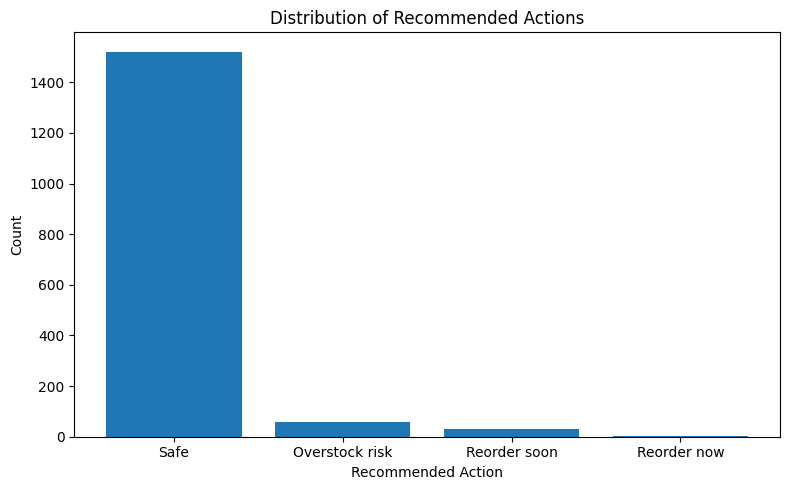

In [14]:
import matplotlib.pyplot as plt

action_counts = latest_decisions["recommended_action"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(action_counts.index, action_counts.values)
plt.title("Distribution of Recommended Actions")
plt.xlabel("Recommended Action")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Step 19.8 — top reorder recommendations

In [15]:
top_reorders = latest_decisions[
    latest_decisions["recommended_action"].isin(["Reorder now", "Reorder soon"])
].sort_values("priority_score", ascending=False)

top_reorders[[
    "date", "store_nbr", "family",
    "forecast_next_7_days",
    "simulated_stock_on_hand",
    "reorder_point",
    "days_until_stockout",
    "recommended_action",
    "priority_score"
]].head(20)

,date,store_nbr,family,forecast_next_7_days,simulated_stock_on_hand,reorder_point,days_until_stockout,recommended_action,priority_score
1429715,2017-08-15,26,MAGAZINES,2.0,1.0,1.0,3.500000,Reorder now,3.500000
1753043,2017-08-15,32,HOME APPLIANCES,2.0,1.0,1.0,3.500000,Reorder now,3.500000
1231003,2017-08-15,23,BOOKS,2.0,1.0,1.0,3.500000,Reorder now,3.500000
2332339,2017-08-15,42,SCHOOL AND OFFICE SUPPLIES,3.0,2.0,1.0,4.666667,Reorder soon,2.333333
1636847,2017-08-15,30,HARDWARE,3.0,2.0,1.0,4.666667,Reorder soon,2.333333
1759779,2017-08-15,32,LINGERIE,6.0,4.0,2.0,4.666667,Reorder soon,2.333333
1645267,2017-08-15,30,LADIESWEAR,10.0,7.0,3.0,4.900000,Reorder soon,2.100000
720751,2017-08-15,13,SCHOOL AND OFFICE SUPPLIES,66.0,47.0,23.0,4.984848,Reorder soon,2.015152
831895,2017-08-15,15,SCHOOL AND OFFICE SUPPLIES,66.0,47.0,23.0,4.984848,Reorder soon,2.015152
554035,2017-08-15,10,SCHOOL AND OFFICE SUPPLIES,21.0,15.0,7.0,5.000000,Reorder soon,2.000000


## Step 19.9 — overstock list

In [16]:
overstock_df = latest_decisions[
    latest_decisions["recommended_action"] == "Overstock risk"
].sort_values("simulated_stock_on_hand", ascending=False)

overstock_df[[
    "date", "store_nbr", "family",
    "forecast_next_7_days",
    "simulated_stock_on_hand",
    "days_until_stockout",
    "recommended_action"
]].head(20)

,date,store_nbr,family,forecast_next_7_days,simulated_stock_on_hand,days_until_stockout,recommended_action
2125207,2017-08-15,39,CLEANING,8983.0,20179.0,15.724480,Overstock risk
1069339,2017-08-15,20,CLEANING,8454.0,17649.0,14.613556,Overstock risk
1124911,2017-08-15,21,CLEANING,8187.0,16763.0,14.332600,Overstock risk
735907,2017-08-15,14,CLEANING,6178.0,13561.0,15.365329,Overstock risk
624763,2017-08-15,12,CLEANING,4861.0,10113.0,14.563053,Overstock risk
1736203,2017-08-15,32,CLEANING,3352.0,7736.0,16.155131,Overstock risk
1625059,2017-08-15,30,CLEANING,3134.0,6920.0,15.456286,Overstock risk
2266663,2017-08-15,41,PERSONAL CARE,2085.0,4371.0,14.674820,Overstock risk
2261611,2017-08-15,41,"LIQUOR,WINE,BEER",563.0,1242.0,15.442274,Overstock risk
2640511,2017-08-15,48,HOME AND KITCHEN II,224.0,591.0,18.468750,Overstock risk


## Step 19.10 — save decision outputs

In [17]:
import os
os.makedirs("data/processed", exist_ok=True)

latest_decisions.to_csv("data/processed/latest_inventory_decisions.csv", index=False)
top_reorders.to_csv("data/processed/top_reorder_recommendations.csv", index=False)
overstock_df.to_csv("data/processed/overstock_risk_list.csv", index=False)

## Step 19.11 — write findings

## Step 19 — Decision layer findings

- A rule-based recommendation engine was created to translate demand and inventory features into business actions.
- The system classifies store-family combinations into `Reorder now`, `Reorder soon`, `Safe`, or `Overstock risk`.
- Priority scores were used to rank the most urgent replenishment needs.
- A latest-date decision snapshot was prepared for dashboard use and operational review.